In [4]:
### Core Simulation Engine

In [5]:
# for sim in simulations:
#    portfolio_value = initial_value
#    for t in time_steps:
#        returns = model.generate_returns()
#        portfolio_value *= (1 + weighted_returns)

In [6]:
### Modern Portforlio Theory

In [7]:
### Option 1 - Single Asset

In [8]:
#r = np.random.normal(mu, sigma)
#value *= (1 + r)

In [9]:
import numpy as np
import matplotlib.pyplot as plt

def monte_portfolio(
    initial_value,
    mu,
    sigma,
    years):
    
    simulations = 10000
    ysteps = 252
    
    dt = 1 / ysteps
    steps = int(years * ysteps)
    
    z = np.random.normal(size=(simulations, steps))
    
    returns = (mu - 0.5 * sigma**2) * dt + sigma * np.sqrt(dt) * z
    
    growth = np.exp(returns)
    
    paths = np.zeros((simulations, steps + 1))
    paths[:, 0] = initial_value
    
    for t in range(1, steps + 1):
        paths[:, t] = paths[:, t-1] * growth[:, t-1]
        
    final_values = paths[:, -1]
    
    mean = np.mean(final_values)
    median = np.median(final_values)
    worst = np.min(final_values)
    best = np.max(final_values)
    prob_loss = np.mean(final_values < initial_value)
    
    plt.figure()
    
    for i in range(50):
        plt.plot(paths[i])
    
    plt.title("Monte-Carlo Portfolio Paths")
    plt.xlabel("Time Steps")
    plt.ylabel("Portfolio Value")
    
    plt.show()
    
    plt.figure()
    
    plt.hist(final_values, bins=100)
    
    plt.title("Distribution of Final Portfolio Values")
    plt.xlabel("Final Portfolio Value")
    plt.ylabel("Frequency")
    
    plt.show()
    
    results = [
        f"Mean final value: ${mean}",
        f"Median final value: ${median}",
        f"Worst outcome: ${worst}",
        f"Best outcome: ${best}",
        f"Probability of loss: {prob_loss: .2%}"
    ]
    for line in results:
        print(line)

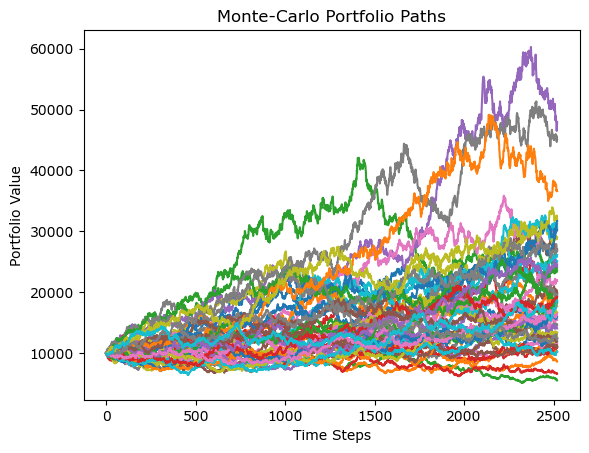

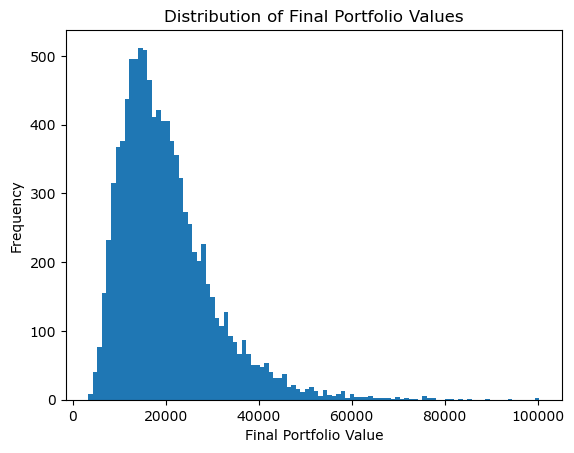

Mean final value: $20265.519540665777
Median final value: $18188.8759194893
Worst outcome: $3420.8984602829246
Best outcome: $100361.40715722929
Probability of loss:  11.17%


In [10]:
monte_portfolio(10000, 0.07, 0.15, 10)

In [11]:
### Option 2 - Correlation Asset

In [12]:
def monte_portfolio_2(
    initial_value,
    mu,
    sigma,
    weights,
    correlation,
    years):
    
    simulations = 10000
    ysteps = 252

    n_assets = len(mu)
    dt = 1 / ysteps
    steps = int(years * ysteps)
    
    cov_matrix = np.outer(sigma, sigma) * correlation
    L = np.linalg.cholesky(cov_matrix)
    
    z = np.random.normal(size=(simulations, steps, n_assets))
    correlated_z = z @ L.T
    
    returns = (mu - 0.5 * sigma**2) * dt + np.sqrt(dt) * correlated_z
    
    portfolio_returns = np.sum(returns * weights, axis=2)
    
    growth = np.exp(portfolio_returns)
    
    paths = np.zeros((simulations, steps + 1))
    paths[:, 0] = initial_value
    
    for t in range(1, steps + 1):
        paths[:, t] = paths[:, t-1] * growth[:, t-1]
        
    final_values = paths[:, -1]
    
    mean = np.mean(final_values)
    median = np.median(final_values)
    worst = np.min(final_values)
    best = np.max(final_values)
    prob_loss = np.mean(final_values < initial_value)
    
    plt.figure()
    
    for i in range(50):
        plt.plot(paths[i])
    
    plt.title("Monte-Carlo Portfolio Paths")
    plt.xlabel("Time Steps")
    plt.ylabel("Portfolio Value")
    
    plt.show()
    
    plt.figure()
    
    plt.hist(final_values, bins=100)
    
    plt.title("Distribution of Final Portfolio Values")
    plt.xlabel("Final Portfolio Value")
    plt.ylabel("Frequency")
    
    plt.show()
    
    results = [
        f"Mean final value: ${mean}",
        f"Median final value: ${median}",
        f"Worst outcome: ${worst}",
        f"Best outcome: ${best}",
        f"Probability of loss: {prob_loss: .2%}"
    ]
    for line in results:
        print(line)

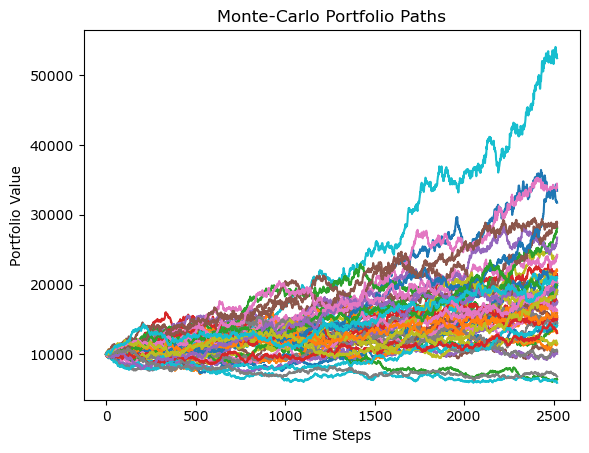

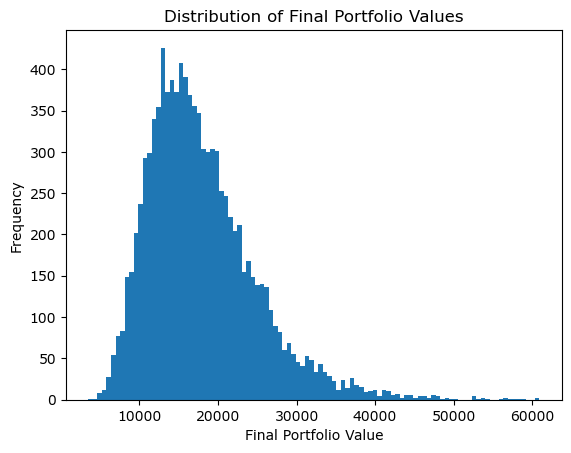

Mean final value: $17922.99316336871
Median final value: $16686.20377550549
Worst outcome: $3517.401053209727
Best outcome: $60902.78502008321
Probability of loss:  8.27%


In [13]:
iv = 10000

mu = np.array([0.08, 0.03, 0.05])
su = np.array([0.18, 0.06, 0.12])

w = np.array([0.6, 0.3, 0.1])

cor = np.array([
    [1.0,  0.2,  0.4],
    [0.2,  1.0,  0.1],
    [0.4,  0.1,  1.0]
])

yr = 10

monte_portfolio_2(iv, mu, su, w, cor, yr)

In [14]:
### Option 3 - Adaptive Weights

In [23]:
def monte_portfolio_3(
    initial_value,
    mu,
    sigma,
    weights,
    correlation,
    years):
    
    simulations = 10000
    ysteps = 252
    rebalance_frequency = 252
    
    n_assets = len(mu)
    dt = 1 / ysteps
    steps = int(years * ysteps)
    
    mu = mu.reshape(1, 1, -1)
    sigma = sigma.reshape(1, 1, -1)
    
    cov_matrix = np.outer(sigma.flatten(), sigma.flatten()) * correlation
    L = np.linalg.cholesky(cov_matrix)
    
    z = np.random.normal(size=(simulations, steps, n_assets))
    correlated_z = z @ L.T
    
    returns = (mu - 0.5 * sigma**2) * dt + np.sqrt(dt) * correlated_z
    
    asset_values = np.zeros((simulations, n_assets))
    asset_values[:] = initial_value * weights
    
    paths = np.zeros((simulations, steps + 1))
    paths[:, 0] = initial_value
    
    weights_2d = weights[None, :]
    
    for t in range(1, steps + 1):
        asset_values *= np.exp(returns[:, t-1, :])
        portfolio_value = np.sum(asset_values, axis=1)
        if t % rebalance_frequency == 0:
            asset_values = portfolio_value[:, None] * weights_2d
        paths[:, t] = portfolio_value
    
    final_values = paths[:, -1]
    
    mean = np.mean(final_values)
    median = np.median(final_values)
    worst = np.min(final_values)
    best = np.max(final_values)
    prob_loss = np.mean(final_values < initial_value)
    
    plt.figure()
    for i in range(50):
        plt.plot(paths[i])
    plt.title("Monte-Carlo Portfolio Paths")
    plt.xlabel("Time Steps")
    plt.ylabel("Portfolio Value")
    plt.show()
    
    plt.figure()
    plt.hist(final_values, bins=100)
    plt.title("Distribution of Final Portfolio Values")
    plt.xlabel("Final Portfolio Value")
    plt.ylabel("Frequency")
    plt.show()
    
    results = [
        f"Mean final value: ${mean:,.0f}",
        f"Median final value: ${median:,.0f}",
        f"Worst outcome: ${worst:,.0f}",
        f"Best outcome: ${best:,.0f}",
        f"Probability of loss: {prob_loss:.2%}"
    ]
    
    for line in results:
        print(line)

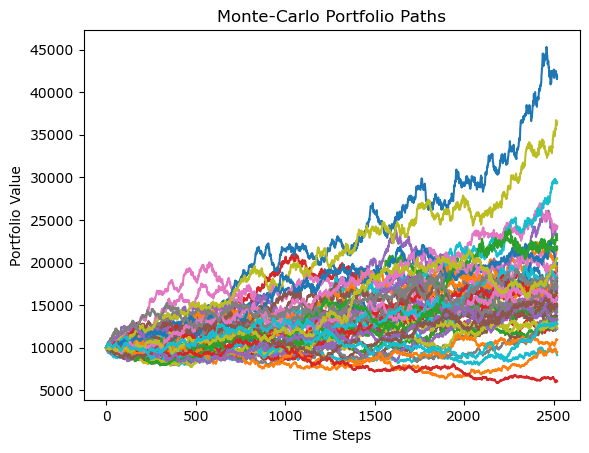

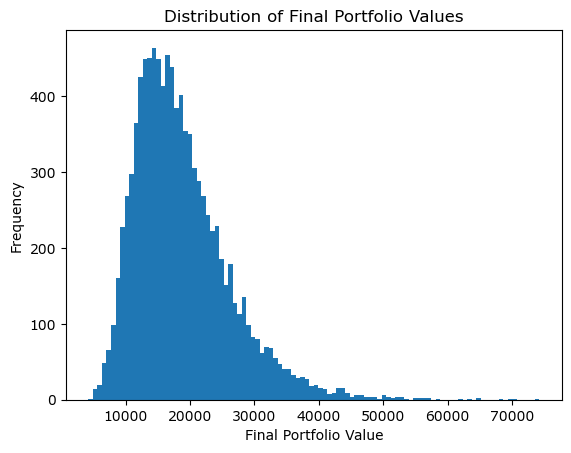

Mean final value: $18,753
Median final value: $17,376
Worst outcome: $4,233
Best outcome: $74,254
Probability of loss: 6.76%


In [24]:
iv = 10000

mu = np.array([0.08, 0.03, 0.05])
su = np.array([0.18, 0.06, 0.12])

w = np.array([0.6, 0.3, 0.1])

cor = np.array([
    [1.0,  0.2,  0.4],
    [0.2,  1.0,  0.1],
    [0.4,  0.1,  1.0]
])

yr = 10

monte_portfolio_3(iv, mu, su, w, cor, yr)